In [ ]:
%cd ..

In [12]:
import torch

filepath = "data/pt/100/Cuboid3.pt"

data = torch.load(filepath, weights_only=False)

params = data["params"]
graphs = data["graphs"]
mesh_path = data["mesh_path"]
source_path = data["source_path"]

print(params)
print(source_path)
print(mesh_path)

{'node_dim': 7, 'edge_dim': 4, 'output_dim': 9, 'num_categorical': 1, 'builder_kind': 'base'}
data/npz/100/Cuboid3.npz
resources/meshes/cubes/coarse/Cuboid3.msh


In [31]:
import torch.nn.functional as F

from meshnet.mgn.graph_visualizer import GraphVisualizer
from meshnet.mgn.utils import stress_from_displacement
from meshnet.utils.mesh import Mesh

mesh = Mesh.read(data["mesh_path"])
print(mesh.surface.extents)

visualizer = GraphVisualizer(mesh.surface)


g = graphs[11].clone()
u = g.y[..., :3]
true_sigma = g.y[..., 3:9]
_, pred_sigma, _ = stress_from_displacement(g.x, g.edge_index, u, E=2.0e9, nu=0.35)

error = F.l1_loss(pred_sigma, true_sigma, reduction="mean")
print(f"Mean L1 loss for stress prediction: {error.item():.6f}")


[0.05 0.05 0.05]
Mean L1 loss for stress prediction: 114.198227


In [ ]:
visualizer.displacement(g)

Widget(value='<iframe src="http://localhost:41315/index.html?ui=P_0x72a790338ef0_12&reconnect=auto" class="pyv…

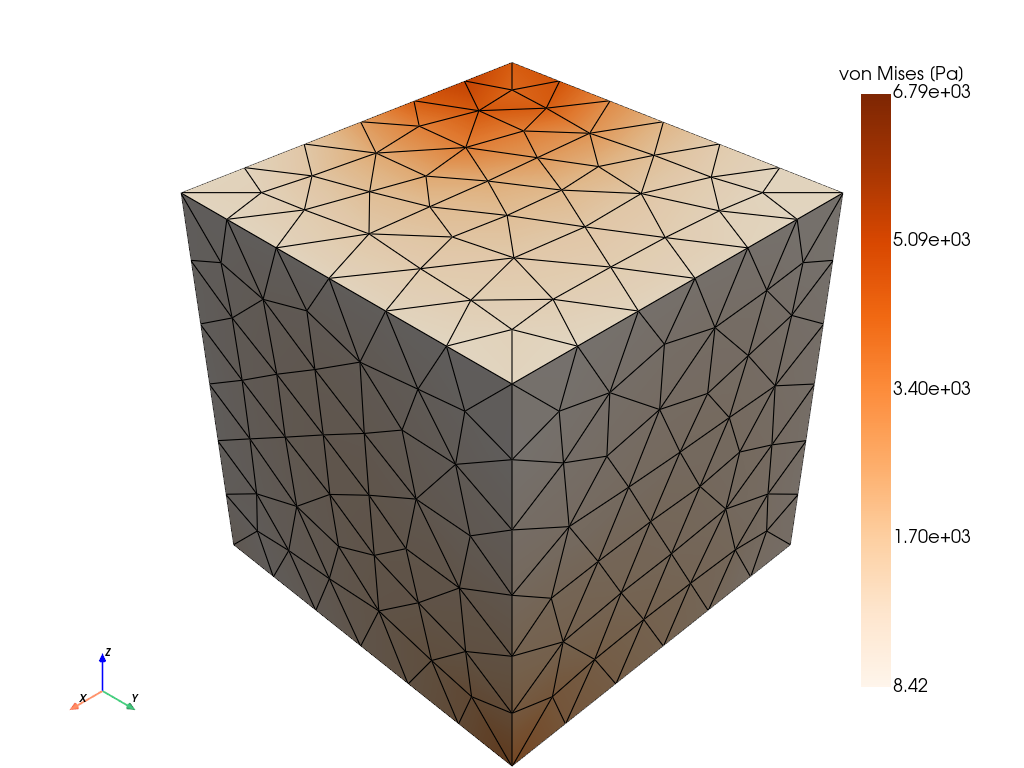

In [29]:
visualizer.von_mises(g)

Widget(value='<iframe src="http://localhost:41315/index.html?ui=P_0x72a7903385c0_13&reconnect=auto" class="pyv…

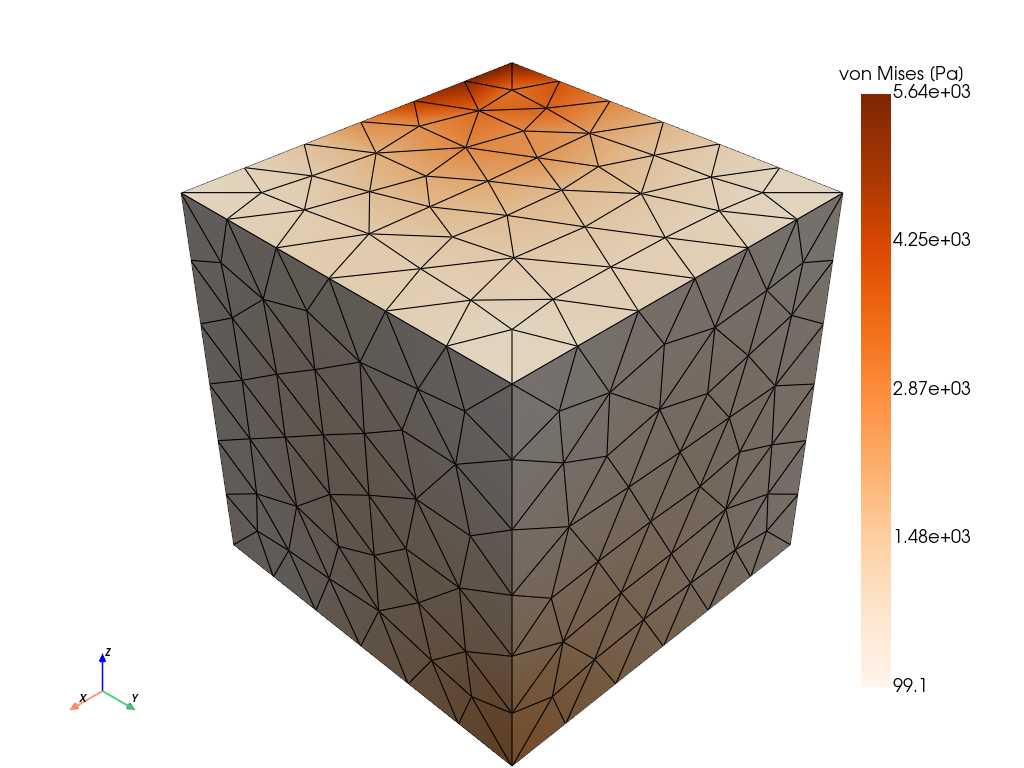

In [30]:
g.y[..., 3:9] = pred_sigma
visualizer.von_mises(g)